<a href="https://colab.research.google.com/github/HSOPedro/C11B/blob/main/Cap_6_EXERCICIOS_(Partes_1_e_2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- 1. Por meio do dataset paises.csv, trace dois gráficos de linhas em
um mesmo plano cartesiano, um mostrando a taxa de mortalidade
(Deathrate) e outro a taxa de natalidade (Birthrate) dos países da
América do Norte;
- 2. Por meio do dataset space.csv, trace um gráfico em barras
mostrando quantas empresas espaciais diferentes os EUA e a CHINA
possuem;
Dica: não se esqueça de retirar os resultados repetidos
- 3. Por meio do dataset space.csv, trace um gráfico em torta
ilustrando a porcentagem de missões da empresa Roscosmos que
deram certo e que deram errado;
- 4. Utilizando o dataset space.csv, trace um gráfico em barras com as
- 5 empresas que mais tiveram missões com status “Failure”;

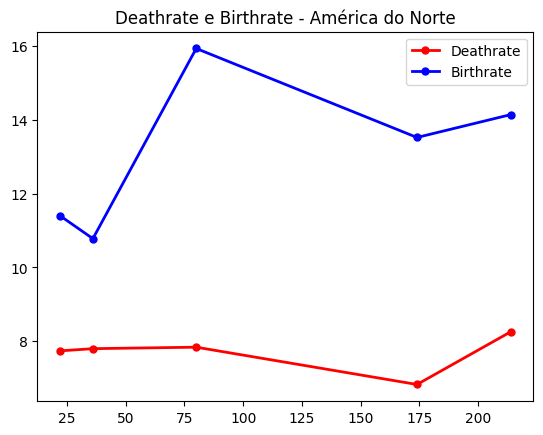

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

d_paises = pd.read_csv('paises.csv', sep=';')

paises_an = d_paises.loc[d_paises['Region'].str.strip() == 'NORTHERN AMERICA']

plt.plot(paises_an['Deathrate'], '.-r',
         paises_an['Birthrate'], '.-b',
         linewidth='2', markersize=10)

plt.title('Deathrate e Birthrate - América do Norte')
plt.legend(['Deathrate', 'Birthrate'])
plt.show()

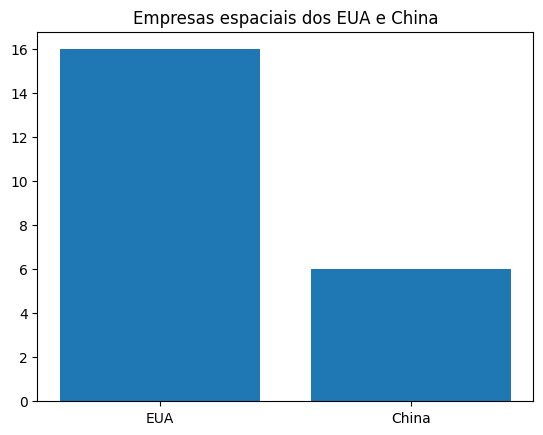

In [12]:
d_space = pd.read_csv('space.csv', delimiter=';')

eua = d_space.loc[d_space['Location'].str.contains('USA')]
china = d_space.loc[d_space['Location'].str.contains('China')]

eua = eua['Company Name'].drop_duplicates()
china = china['Company Name'].drop_duplicates()

dados = [len(eua), len(china)]

plt.bar(['EUA', 'China'], dados)

plt.title('Empresas espaciais dos EUA e China')
plt.show()

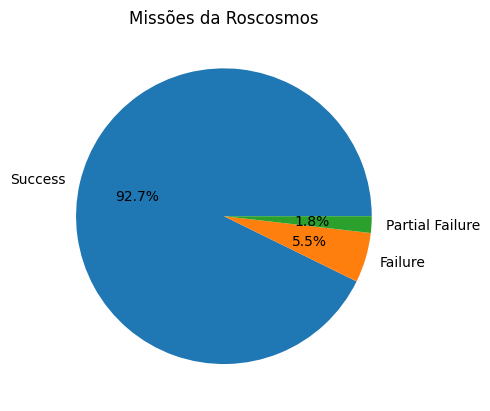

In [16]:
roscosmos = d_space.loc[d_space['Company Name'] == 'Roscosmos']

situacao = roscosmos['Status Mission'].value_counts()

plt.pie(situacao,
        labels=situacao.index,
        autopct='%1.1f%%')

plt.title('Missões da Roscosmos')
plt.show()

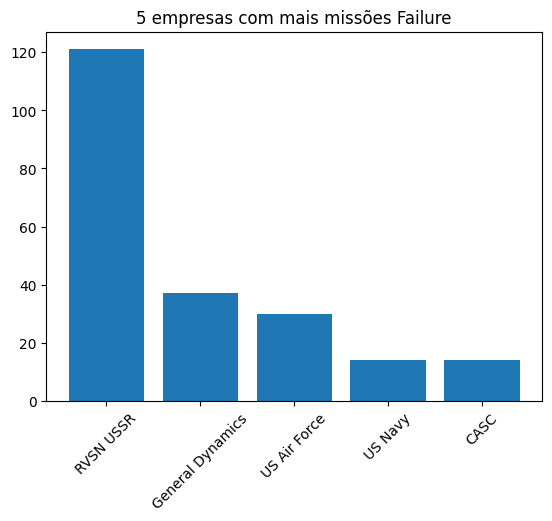

In [15]:
falhas = d_space.loc[d_space['Status Mission'] == 'Failure']

empresas = falhas['Company Name'].value_counts().head()

plt.bar(empresas.index, empresas.values)

plt.title('5 empresas com mais missões Failure')
plt.xticks(rotation=45)
plt.show()

- 5. Por meio do dataset paises.csv, trace um gráfico de dispersão
relacionando a renda per capita (GDP ($ per capita)) com a taxa de
alfabetização (Literacy (%)) dos países da América Latina. Além disso,
faça com que o tamanho de cada ponto represente a população do país;

- 6. Com base nos dados do dataset space.csv, trace um gráfico em torta
ilustrando a porcentagem geral de foguetes com status “StatusActive” e
“StatusRetired”, considerando todas as empresas;

- 7. Por meio do dataset paises.csv, trace em uma mesmo plano cartesiano
duas linhas com estilos customizados (marcador, cor e tipo de linhas
diferentes) comparando o “GDP ($ per capita)” e o número de “Phones
(per 1000)” dos países da Europa Ocidental (WESTERN EUROPE);

- 8. Por meio do dataset space.csv, usando o conceito de subplot(), trace
dois gráficos de barras separados lado a lado: à esquerda, as 5 empresas
com mais missões de sucesso; à direita, as 5 empresas com mais missões
de falha.


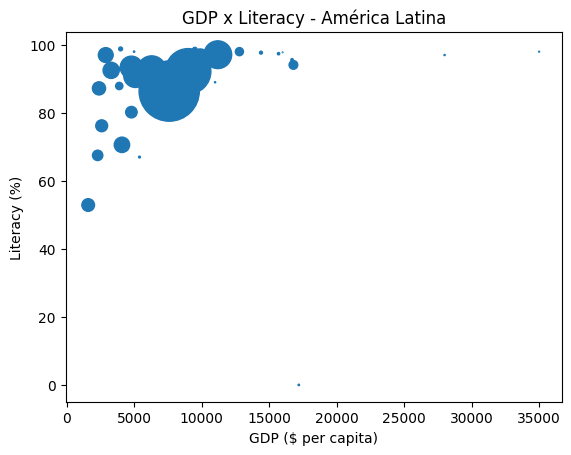

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

d_paises = pd.read_csv('paises.csv', sep=';')

america_latina = d_paises.loc[
    d_paises['Region'].str.contains('LATIN AMER. & CARIB')
]

plt.scatter(
    america_latina['GDP ($ per capita)'],
    america_latina['Literacy (%)'],
    s=america_latina['Population'] / 100000
)

plt.title('GDP x Literacy - América Latina')
plt.xlabel('GDP ($ per capita)')
plt.ylabel('Literacy (%)')
plt.show()

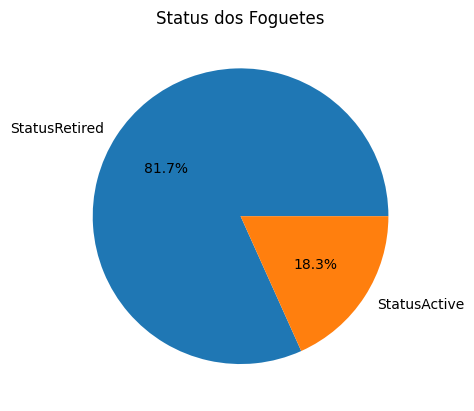

In [18]:
status = d_space['Status Rocket'].value_counts()

plt.pie(
    status,
    labels=status.index,
    autopct='%1.1f%%'
)

plt.title('Status dos Foguetes')
plt.show()

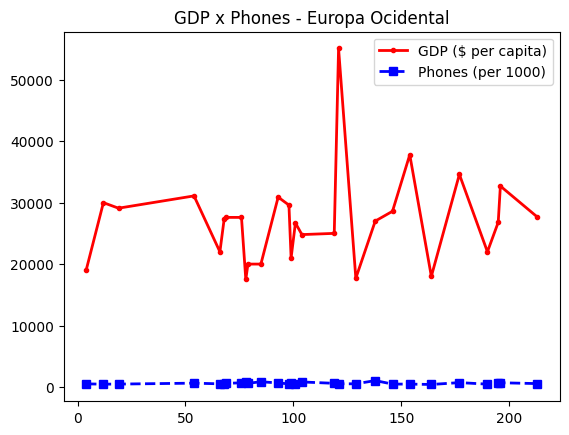

In [19]:
europa = d_paises.loc[
    d_paises['Region'].str.contains('WESTERN EUROPE')
]

plt.plot(
    europa['GDP ($ per capita)'],
    '.-r',
    linewidth=2
)

plt.plot(
    europa['Phones (per 1000)'],
    's--b',
    linewidth=2
)

plt.title('GDP x Phones - Europa Ocidental')
plt.legend(['GDP ($ per capita)', 'Phones (per 1000)'])
plt.show()

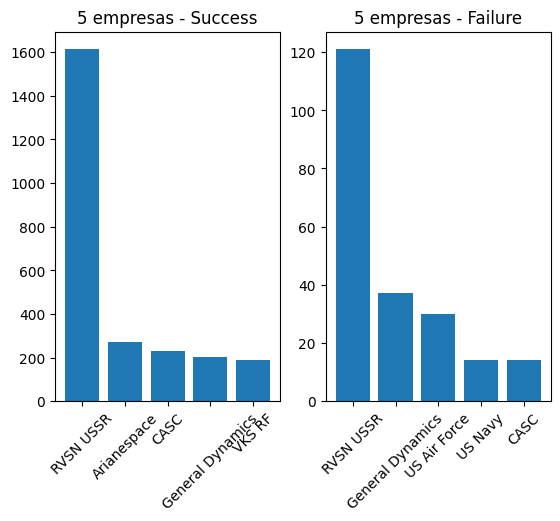

In [20]:
sucesso = d_space.loc[
    d_space['Status Mission'] == 'Success'
]

falha = d_space.loc[
    d_space['Status Mission'] == 'Failure'
]

empresas_sucesso = sucesso['Company Name'].value_counts().head()
empresas_falha = falha['Company Name'].value_counts().head()

plt.subplot(1, 2, 1)
plt.bar(empresas_sucesso.index, empresas_sucesso.values)
plt.title('5 empresas - Success')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.bar(empresas_falha.index, empresas_falha.values)
plt.title('5 empresas - Failure')
plt.xticks(rotation=45)

plt.show()